# Bitcoin Foundation Models

## Role
Artifact-first analysis plus safely gated regeneration capability for the two completed zero-shot systems.

## Inputs
Canonical target and frozen Chronos, TimesFM, and validated vectors; optional model checkpoints only when generation is explicitly enabled.

## Outputs
Artifact-derived comparison by default; when explicitly enabled, candidate forecasts only under `results/staging/bitcoin/<run-id>/`; authoritative replacement only through a separately gated validation-and-promotion step.

## Depends On
01 and 07.

## Authoritative Status
AUTHORITATIVE MODEL ANALYSIS / GATED GENERATION

## What This Notebook Does Not Do
Default Run All does not download checkpoints, load models, generate forecasts, or promote artifacts. It never fine-tunes models, and generation never writes directly to authoritative result paths.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.bitcoin_pipeline import *
RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False


In [2]:
pd.DataFrame({'Model':['Chronos-Bolt-Tiny','TimesFM'],'Checkpoint':['amazon/chronos-bolt-tiny','google/timesfm-2.5-200m-pytorch'],'Zero-shot':[True,True],'Context':[128,128],'Context end':['t-1','t-1'],'Horizon':[1,1],'Targets':[1061,1061]})

,Model,Checkpoint,Zero-shot,Context,Context end,Horizon,Targets
0,Chronos-Bolt-Tiny,amazon/chronos-bolt-tiny,True,128,t-1,1,1061
1,TimesFM,google/timesfm-2.5-200m-pytorch,True,128,t-1,1,1061


In [3]:
# Load the canonical split and frozen foundation forecasts.
_, target = load_bitcoin_target(ROOT)
train, test = canonical_split(target)
validated = load_validated_forecasts(ROOT)

# Compute and display the unchanged foundation-model metrics.
metric_table(
    validated.Actual,
    {
        'Chronos-Bolt-Tiny': validated.Chronos_Bolt_Tiny,
        'TimesFM': validated.TimesFM,
    },
    train,
).sort_values('RMSE')

,MAE,RMSE,MAPE,sMAPE,MASE,N
Model,,,,,,
TimesFM,1349.946786,1924.199337,1.823179,1.823895,4.786953,1061
Chronos-Bolt-Tiny,1424.025828,1994.007926,1.934509,1.928782,5.049640,1061


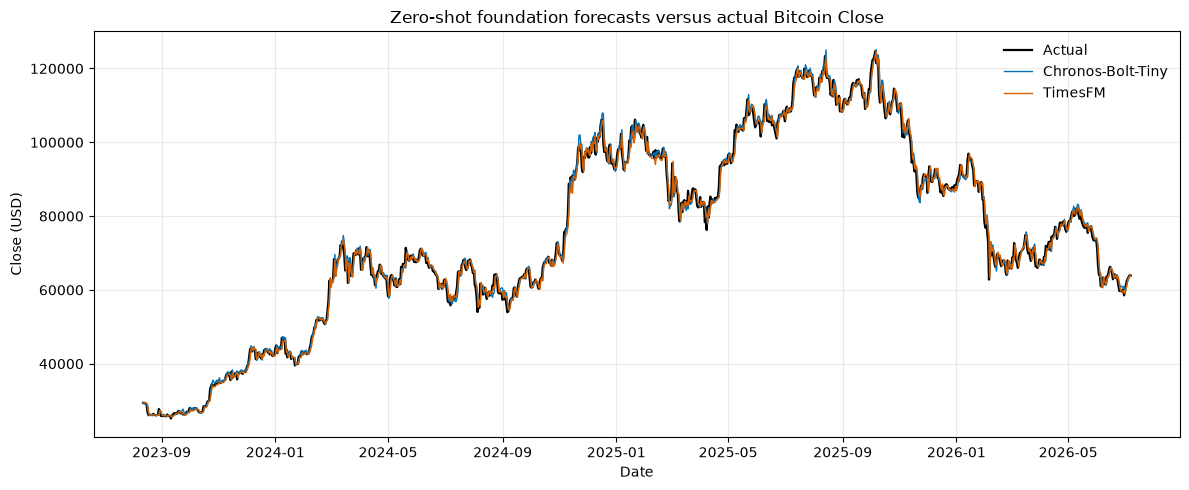

In [4]:
import matplotlib.pyplot as plt

# Overlay both frozen foundation forecasts on held-out actual prices.
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(validated.index, validated.Actual, color='black', linewidth=1.6, label='Actual')
ax.plot(validated.index, validated.Chronos_Bolt_Tiny, color='#0072B2', linewidth=1.0, label='Chronos-Bolt-Tiny')
ax.plot(validated.index, validated.TimesFM, color='#D55E00', linewidth=1.0, label='TimesFM')
ax.set(title='Zero-shot foundation forecasts versus actual Bitcoin Close', xlabel='Date', ylabel='Close (USD)')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Foundation interval reliability

The embedded PNG was verified against `foundation_uncertainty_summary.csv` and `bitcoin_uncertainty_evidence_v2.csv`: native/calibrated 80% coverage is 84.54%/81.53% for Chronos and 33.08%/55.61% for TimesFM.

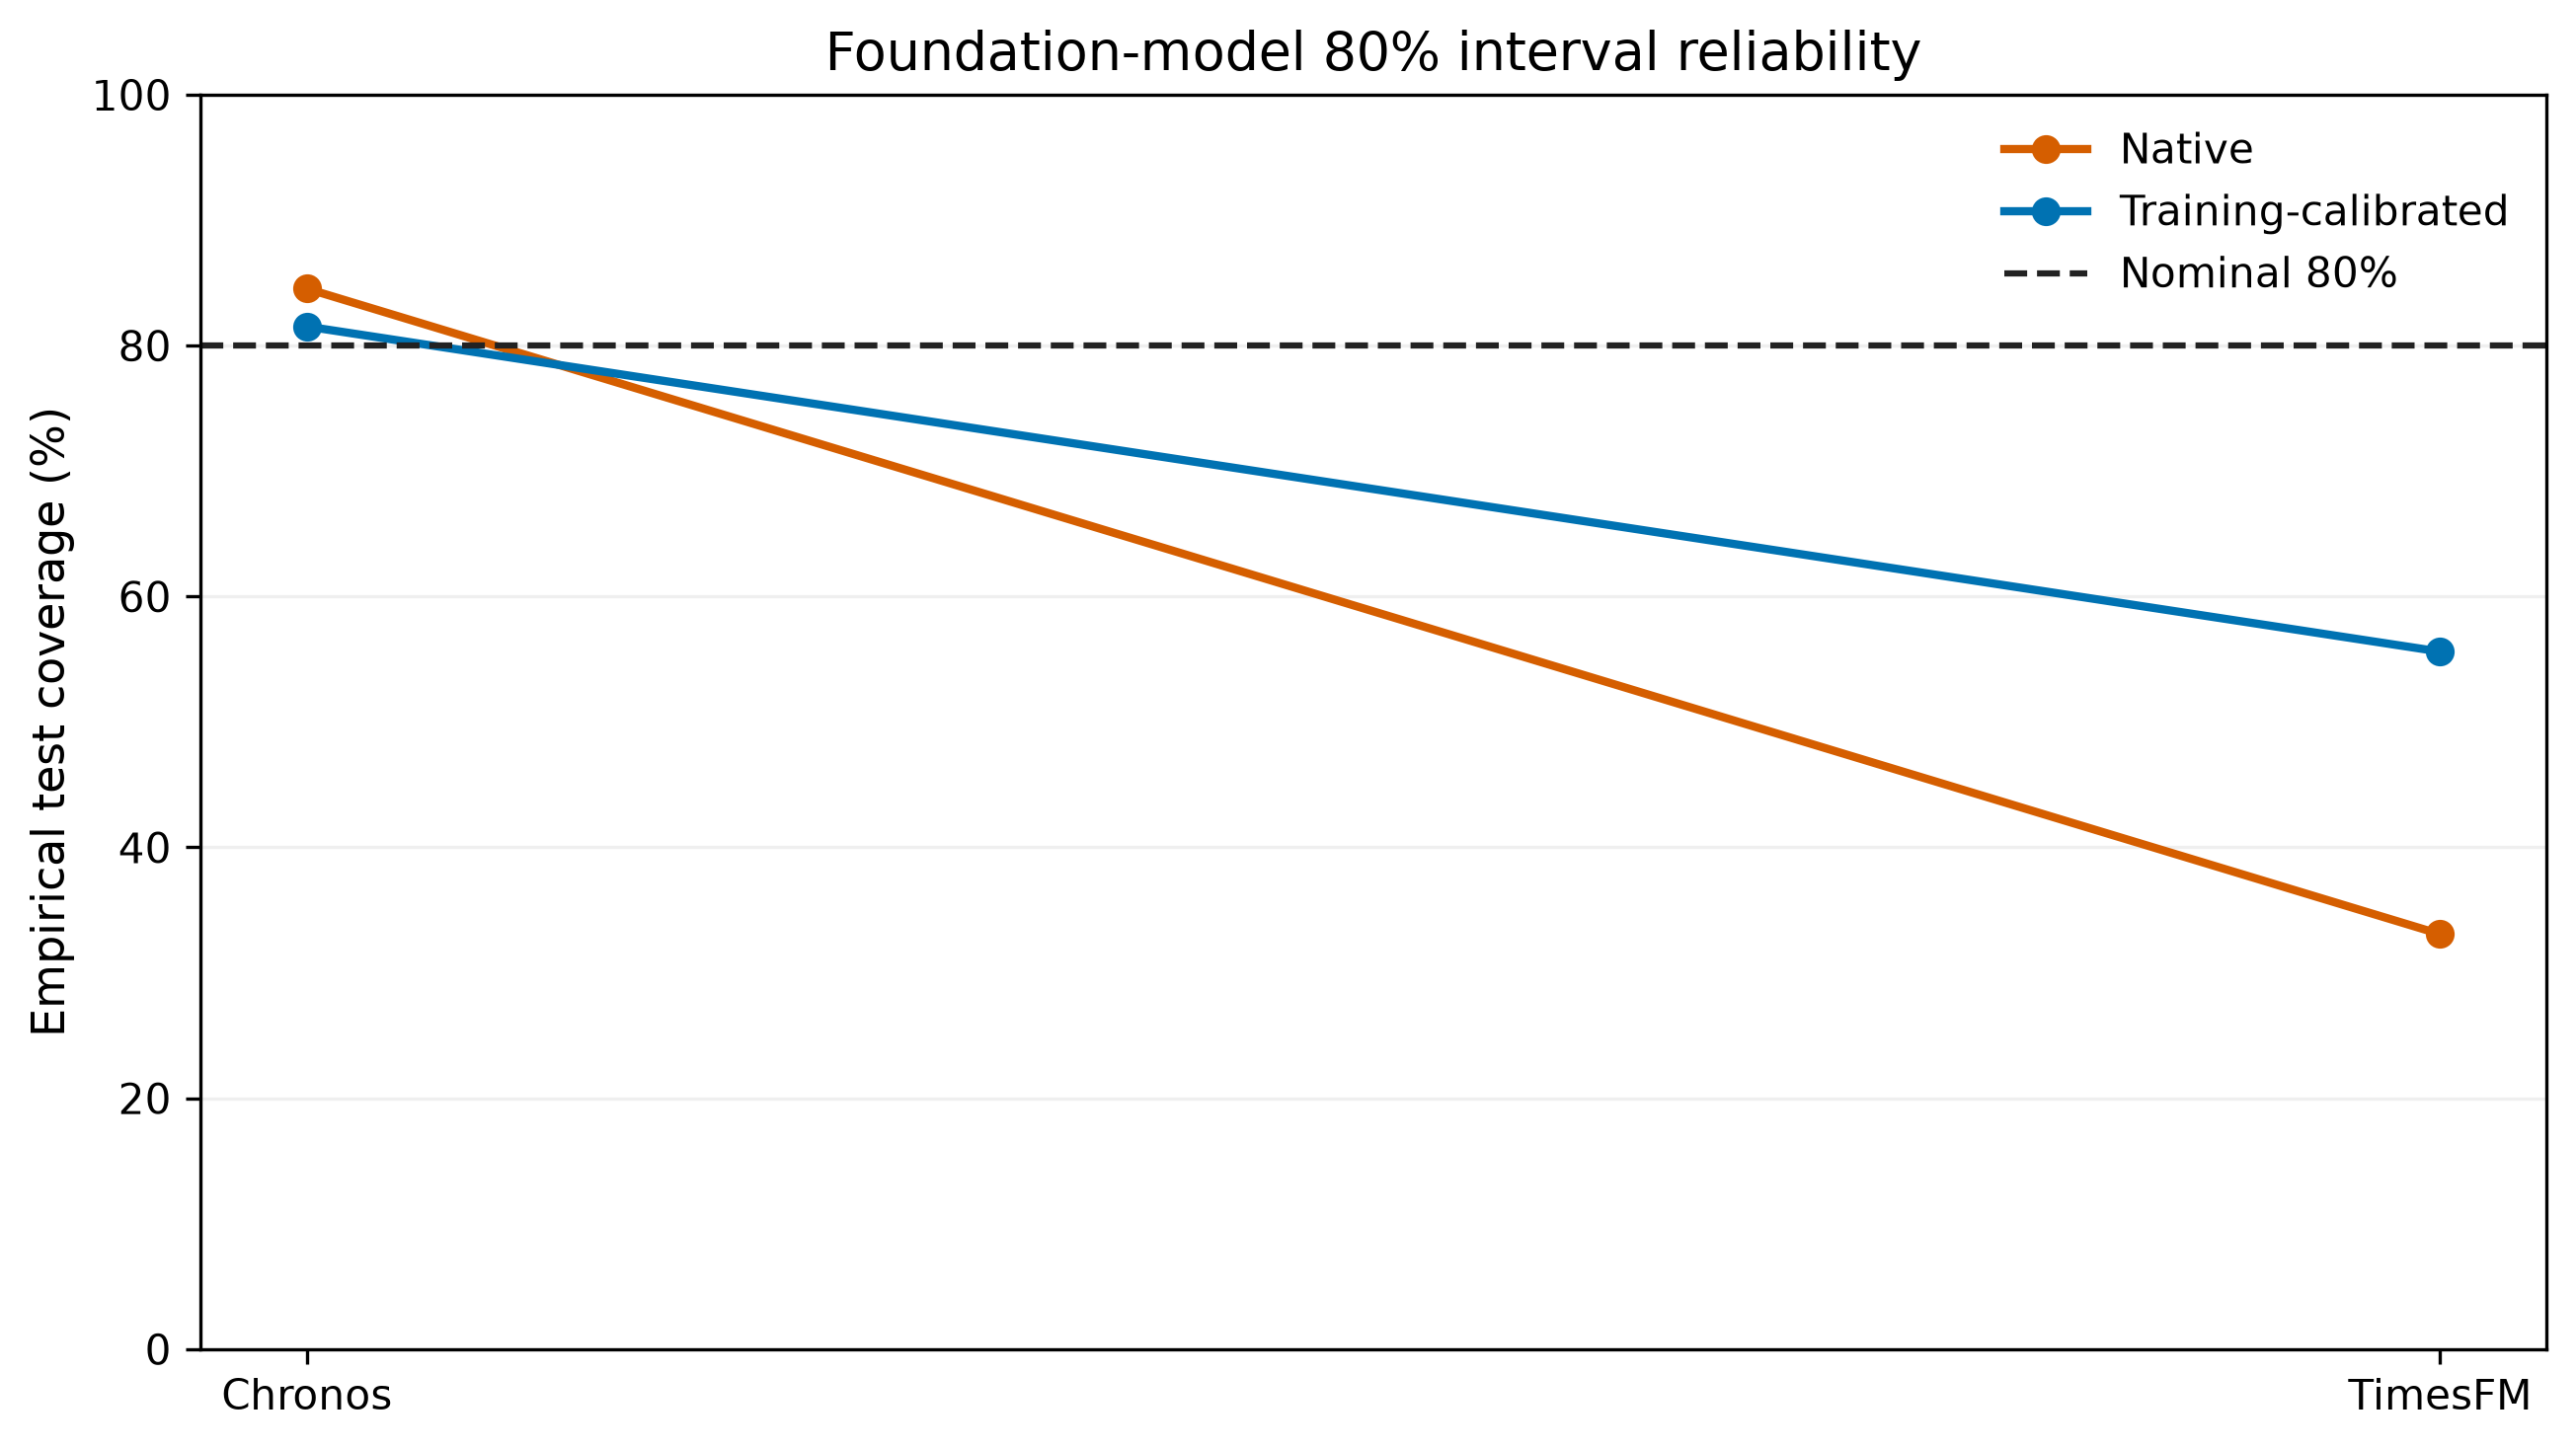

In [5]:
from IPython.display import Image, display

# Display the verified frozen-data reliability figure without recomputation.
display(Image(filename=str(ROOT / 'figures' / 'bitcoin' / 'bitcoin_uncertainty_reliability.png')))

## Explicitly gated candidate generation
Set `RUN_GENERATION=True` and replace the placeholder run ID only in an intentional generation run. Each forecast uses exactly the 128 observations strictly before its forecast timestamp. Candidate CSVs are written only to staging; normal Run All skips imports, checkpoint loading, inference, and writes.

In [6]:
FOUNDATION_RUN_ID = 'SET-AN-EXPLICIT-RUN-ID'
EXPECTED_STAGED_SHA256 = {
    'Chronos_Bolt_Tiny': None,
    'TimesFM': None,
}

if RUN_GENERATION:
    if FOUNDATION_RUN_ID == 'SET-AN-EXPLICIT-RUN-ID':
        raise ValueError('Set a unique FOUNDATION_RUN_ID before generation.')
    import torch
    from chronos import BaseChronosPipeline
    import timesfm

    contexts = []
    for forecast_date in test.index:
        context = target.loc[target.index < forecast_date].tail(128).to_numpy(dtype=np.float32)
        if len(context) != 128:
            raise ValueError(f'Expected 128 strictly past observations for {forecast_date}; got {len(context)}')
        contexts.append(context)
    context_matrix = np.stack(contexts)
    assert context_matrix.shape == (1061, 128)

    chronos = BaseChronosPipeline.from_pretrained(
        'amazon/chronos-bolt-tiny', device_map='cpu', torch_dtype=torch.float32
    )
    chronos_points = []
    for start in range(0, len(context_matrix), 32):
        _, quantiles = chronos.predict_quantiles(
            torch.tensor(context_matrix[start:start + 32]),
            prediction_length=1, quantile_levels=[0.1, 0.5, 0.9],
        )
        chronos_points.extend(quantiles[:, 0, 1].detach().cpu().numpy())

    timesfm_model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
        'google/timesfm-2.5-200m-pytorch', torch_compile=False
    )
    timesfm_model.compile(timesfm.ForecastConfig(
        max_context=128, max_horizon=1, normalize_inputs=True, per_core_batch_size=32
    ))
    timesfm_points, _ = timesfm_model.forecast(horizon=1, inputs=list(context_matrix))
    timesfm_points = np.asarray(timesfm_points)[:, 0]

    staging_dir = ROOT / 'results' / 'staging' / 'bitcoin' / FOUNDATION_RUN_ID
    staging_dir.mkdir(parents=True, exist_ok=False)
    staged = {
        'Chronos_Bolt_Tiny': staging_dir / 'chronos_bolt_tiny_forecast.csv',
        'TimesFM': staging_dir / 'timesfm_forecast.csv',
    }
    for model_column, values in {'Chronos_Bolt_Tiny': chronos_points, 'TimesFM': timesfm_points}.items():
        candidate = pd.DataFrame({'Timestamp': test.index, model_column: np.asarray(values, dtype=float)})
        candidate.to_csv(staged[model_column], index=False)
        validate_staged_forecast(staged[model_column], model_column, test.index)
    staged

## Separately gated authoritative promotion
Promotion is disabled independently. Before enabling it, inspect each staged CSV and record its reviewed SHA-256 in `EXPECTED_STAGED_SHA256`. The shared promotion helper then revalidates exact schema, 1,061 timestamps/rows, finite values, and the recorded hash before replacing an authoritative file.

In [7]:
if PROMOTE_TO_AUTHORITATIVE:
    if not RUN_GENERATION:
        raise PermissionError('Promotion requires the same intentional run to have RUN_GENERATION=True.')
    authoritative = {
        'Chronos_Bolt_Tiny': ROOT / 'results' / 'chronos_bolt_tiny_forecast.csv',
        'TimesFM': ROOT / 'results' / 'timesfm_forecast.csv',
    }
    for model_column, destination in authoritative.items():
        reviewed_hash = EXPECTED_STAGED_SHA256[model_column]
        if not reviewed_hash:
            raise ValueError(f'Record the reviewed staged SHA-256 for {model_column} before promotion.')
        promote_staged_forecast(
            staged[model_column], destination, model_column, test.index,
            explicit_opt_in=True, expected_hash=reviewed_hash,
        )

## Limitation
Foundation-model pretraining overlap with this Bitcoin period cannot be ruled out from local evidence. No contamination is asserted.

## Key Findings

Chronos-Bolt-Tiny and TimesFM are evaluated as frozen zero-shot, horizon-one forecasts with identical 128-observation context lengths. Their trajectories and metric table show materially different point accuracy, while the verified reliability figure shows that training-only calibration moves both 80% coverages toward nominal; pretraining-period overlap remains unresolved.